In [1]:
import os
from PIL import Image
import json
import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms, datasets
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [2]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.Grayscale(num_output_channels=3),
    transforms.ToTensor(),
    transforms.Normalize([0.5, 0.5, 0.5],
                         [0.5, 0.5, 0.5])
])

In [3]:
with open("../data/processed/class_mapping.json", "r") as f:
    class_mapping = json.load(f)

class_mapping = class_mapping["class_to_index"]

idx_to_class = {v: k for k, v in class_mapping.items()}
num_classes = len(idx_to_class)

In [4]:
model = models.mobilenet_v2(weights=None)

in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, num_classes)

device = torch.device("cpu")
model.load_state_dict(torch.load("best_model_finetuned.pth", map_location="cpu"))
model = model.to(device)
model.eval()
print("Model loaded on CPU")

Model loaded on CPU


In [5]:
train_loss = [0.7219, 0.3995, 0.3584, 0.3479, 0.3369, 0.3275, 0.3180, 0.3231, 0.3163, 0.3191]
val_loss   = [0.2865, 0.2052, 0.1788, 0.1602, 0.1328, 0.1329, 0.1185, 0.1206, 0.1159, 0.1289]

train_acc  = [79.90, 87.38, 88.19, 88.53, 89.00, 89.22, 89.57, 89.53, 89.70, 89.53]
val_acc    = [92.22, 93.76, 94.28, 95.05, 95.89, 95.75, 96.14, 96.06, 96.22, 95.68]

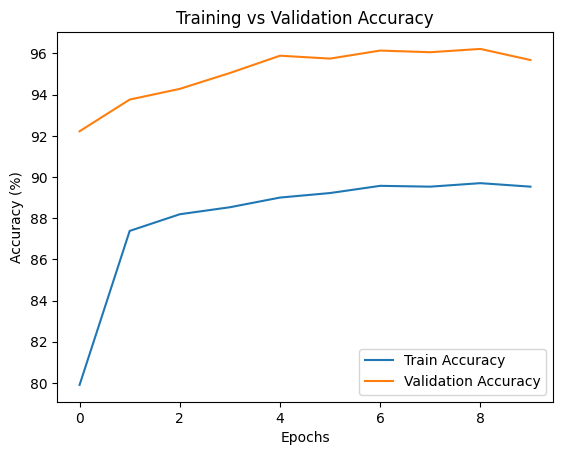

In [6]:
plt.figure()
plt.plot(train_acc, label="Train Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy (%)")
plt.legend()
plt.show()

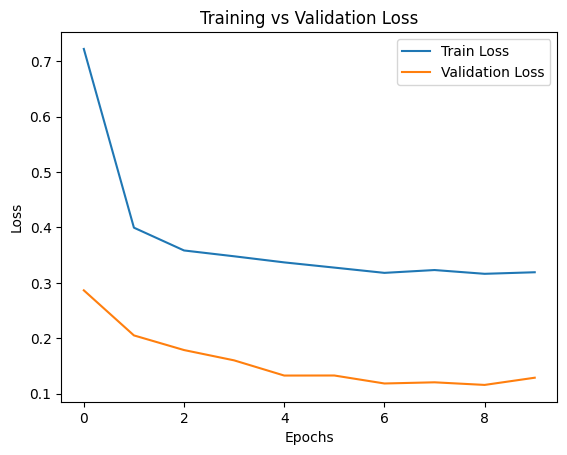

In [7]:
plt.figure()
plt.plot(train_loss, label="Train Loss")
plt.plot(val_loss, label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [8]:
test_dir = "../data/raw/test"

X_test = []
y_test = []

for file in os.listdir(test_dir):
    if file.endswith(".jpg"):
        label = file.split("_")[0]   # A_test.jpg → A
        
        img_path = os.path.join(test_dir, file)
        image = Image.open(img_path).convert("RGB")
        image = transform(image)

        X_test.append(image)
        y_test.append(label)

print("Loaded samples:", len(X_test))

Loaded samples: 28


In [9]:
y_test = [class_mapping[label] for label in y_test]

idx_to_class = {v: k for k, v in class_mapping.items()}

X_test = torch.stack(X_test)
y_test = torch.tensor(y_test)

In [10]:
test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
viz_loader = DataLoader(test_dataset, batch_size=16, shuffle=True)

In [11]:
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)
        confidences, preds = torch.max(probs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

In [12]:
accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 100.00%


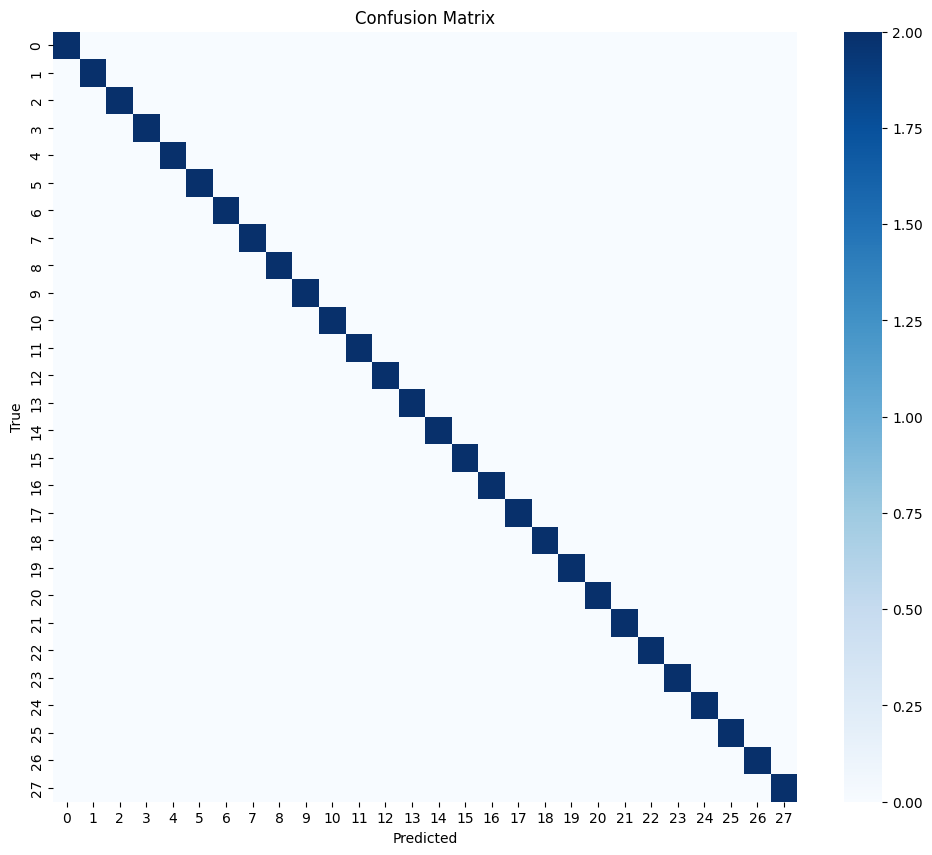

In [13]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

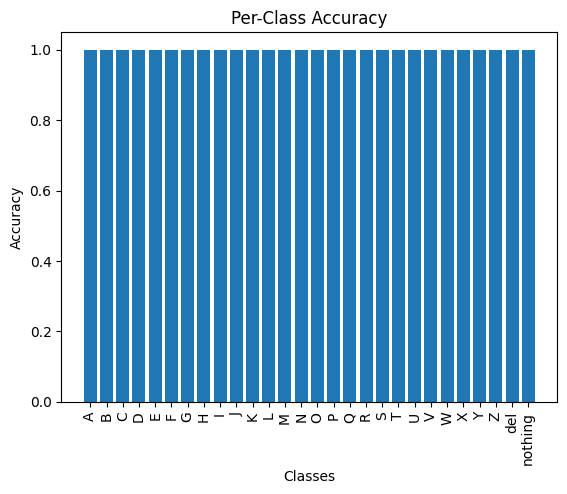

In [14]:
class_acc = cm.diagonal() / cm.sum(axis=1)

labels = [idx_to_class[i] for i in range(len(class_acc))]

plt.figure()
plt.bar(labels, class_acc)
plt.xticks(rotation=90)
plt.title("Per-Class Accuracy")
plt.xlabel("Classes")
plt.ylabel("Accuracy")
plt.show()

In [15]:
labels = sorted(set(all_labels))

report = classification_report(
    all_labels,
    all_preds,
    labels=labels,
    target_names=[idx_to_class[i] for i in labels]
)

print(report)

              precision    recall  f1-score   support

           A       1.00      1.00      1.00         2
           B       1.00      1.00      1.00         2
           C       1.00      1.00      1.00         2
           D       1.00      1.00      1.00         2
           E       1.00      1.00      1.00         2
           F       1.00      1.00      1.00         2
           G       1.00      1.00      1.00         2
           H       1.00      1.00      1.00         2
           I       1.00      1.00      1.00         2
           J       1.00      1.00      1.00         2
           K       1.00      1.00      1.00         2
           L       1.00      1.00      1.00         2
           M       1.00      1.00      1.00         2
           N       1.00      1.00      1.00         2
           O       1.00      1.00      1.00         2
           P       1.00      1.00      1.00         2
           Q       1.00      1.00      1.00         2
           R       1.00    

In [16]:
misclassified = []

for true, pred in zip(all_labels, all_preds):
    if true != pred:
        misclassified.append((idx_to_class[true], idx_to_class[pred]))

from collections import Counter
mis_counts = Counter(misclassified)

print("Top Misclassifications:")
for (true, pred), count in mis_counts.most_common(10):
    print(f"{true} → {pred}: {count}")

Top Misclassifications:


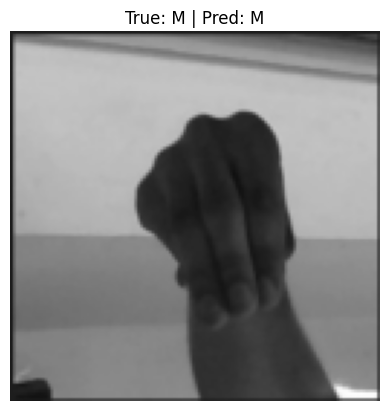

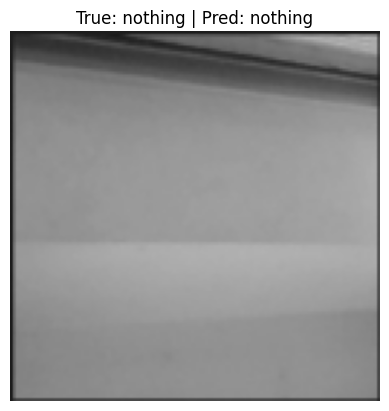

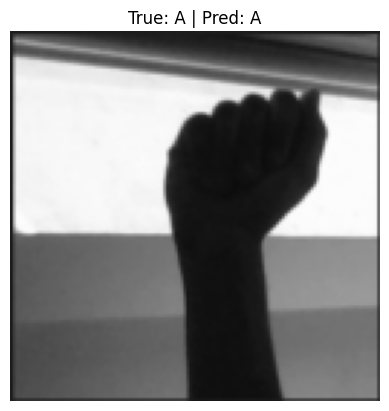

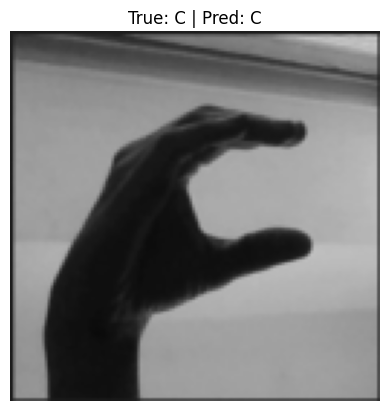

In [17]:
count = 0
for images, labels in viz_loader:
    outputs = model(images.to(device))
    _, preds = torch.max(outputs, 1)

    for i in range(len(images)):
        img = images[i].cpu().permute(1,2,0).numpy()
        img = (img + 1) / 2

        true_label = idx_to_class[labels[i].item()]
        pred_label = idx_to_class[preds[i].item()]

        plt.imshow(img)
        plt.title(f"True: {true_label} | Pred: {pred_label}")
        plt.axis("off")
        plt.show()

        count += 1
        if count == 4:
            break
    if count == 4:
        break

In [18]:
print("\n      FINAL EVALUATION SUMMARY      ")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Number of test samples: {len(all_labels)}")
print(f"Number of classes evaluated: {len(set(all_labels))}")


      FINAL EVALUATION SUMMARY      
Accuracy: 100.00%
Number of test samples: 56
Number of classes evaluated: 28


The evaluation results indicate that the trained MobileNetV2 model performs really well on the test dataset, achieving an overall accuracy of 100%. The confusion matrix shows perfect classification with all predictions along the diagonal showing no misclassifications among the evaluated classes. Also the precision, recall and F1-score for each class are all equal to 1.00 showing consistent and reliable performance across all gestures. But it is important to note that the test dataset is limited with only one sample per class which may not fully capture real world variability. The results suggest that the model has successfully learned the distinguishing features of the ASL gestures and is capable of accurate classification under controlled conditions.